# Streaming Vocos export (clean)

This notebook keeps only inference and export steps for Streaming Vocos with Kokoro:
- clean one-shot inference path
- text-to-audio playback in notebook
- ONNX export
- LiteRT (TFLite) export


In [31]:
import math
import os
from pathlib import Path

import onnx
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.io.wavfile as wavfile
from IPython.display import Audio, display

try:
    import ai_edge_torch
except Exception:
    ai_edge_torch = None

from kokoro import KModel, KPipeline
from kokoro.model import KModelForONNX
from streaming_vocos import StreamingVocos

os.environ['CUDA_VISIBLE_DEVICES'] = ''
torch.set_num_threads(8)

OPSET_VERSION = 19
MAX_INPUT_LENGTH = 510
SAMPLE_RATE = 24000
CONFIG_FILE = 'checkpoints/config.json'
CHECKPOINT_PATH = 'checkpoints/kokoro-v1_0.pth'
VOICE_PATH = 'checkpoints/voices/af_heart.pt'
VOCOS_CKPT = 'vocos_fp16.pt'
VOCOS_HOP_LENGTH = 300
VOCOS_CHUNK_MS = 100
VOCOS_CHUNK_FRAMES = max(1, round((VOCOS_CHUNK_MS / 1000.0) * SAMPLE_RATE / VOCOS_HOP_LENGTH))
VOCOS_CHUNK_SAMPLES = VOCOS_CHUNK_FRAMES * VOCOS_HOP_LENGTH
EXPORT_DIR = Path('onnx_streaming_vocos')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


In [32]:
# Load base model
kmodel = KModel(config=CONFIG_FILE, model=CHECKPOINT_PATH, disable_complex=True).to('cpu')
model = KModelForONNX(kmodel).eval()


def load_input_ids(pipeline: KPipeline, text: str):
    if pipeline.lang_code in 'ab':
        _, tokens = pipeline.g2p(text)
        for _, phonemes, _ in pipeline.en_tokenize(tokens):
            if not phonemes:
                continue
    else:
        phonemes, _ = pipeline.g2p(text)

    phonemes = phonemes[:MAX_INPUT_LENGTH]
    token_ids = [pipeline.model.vocab.get(p) for p in phonemes]
    token_ids = [i for i in token_ids if i is not None]
    input_ids = torch.LongTensor([[0, *token_ids, 0]]).to(pipeline.model.device)
    return phonemes, input_ids


def load_voice(pipeline: KPipeline, voice_path: str, phonemes):
    pack = pipeline.load_voice(voice_path).to('cpu')
    return pack[len(phonemes) - 1]


def prepare_inputs(model_for_onnx: KModelForONNX, text: str, voice_path: str, speed_value: int = 1):
    pipeline = KPipeline(lang_code='a', model=model_for_onnx.kmodel, device='cpu')
    phonemes, input_ids_raw = load_input_ids(pipeline, text)
    style = load_voice(pipeline, voice_path, phonemes)
    speed = torch.IntTensor([speed_value])

    text_mask = torch.zeros(1, MAX_INPUT_LENGTH, dtype=torch.float32)
    text_mask[0, :input_ids_raw.shape[1]] = 1
    input_ids = torch.nn.functional.pad(input_ids_raw, (0, MAX_INPUT_LENGTH - input_ids_raw.shape[1]))

    return {
        'phonemes': phonemes,
        'input_ids_raw': input_ids_raw,
        'input_ids': input_ids,
        'text_mask': text_mask,
        'style': style,
        'speed': speed,
    }


/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [33]:

# ── Vocoder modules ───────────────────────────────────────────────────────────

class VocosConditionerModule(nn.Module):
    """Runs the non-causal conditioner (kernel=3) once over the FULL feature
    sequence.  Must be called before any chunked streaming through backbone+head.

    Inputs:  features  [B, in_channels, T_f0]
    Outputs: conditioned [B, model_input_channels, T_f0]
    """

    def __init__(self, vocos: StreamingVocos):
        super().__init__()
        self.conditioner = vocos.model.conditioner

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.conditioner(features.float())


class VocosStreamChunk(nn.Module):
    """Functional causal backbone + ISTFT head with explicit streaming state.

    Takes a pre-conditioned chunk (from VocosConditionerModule) and explicit
    state tensors; returns audio and updated state.  All state manipulations
    are pure tensor operations (cat/slice) → fully ONNX-traceable.

    HARDCODED to 8 ConvNeXt layers (the reference checkpoint).

    State layout:
        embed_prev        [B, model_ch,    KCTX]   causal context for embed conv
        cnx{0..7}_prev    [B, backbone_dim, KCTX]  per-layer dwconv context
        istft_buf         [B, win_len – hop]         ISTFT overlap-add tail
    where KCTX = kernel_size – 1 = 6.
    """

    KCTX: int = 6  # kernel_size (7) – 1

    def __init__(self, vocos: StreamingVocos):
        super().__init__()
        gen = vocos.model
        cfg = vocos.config

        if cfg.backbone_layers != 8:
            raise ValueError(
                f"VocosStreamChunk requires exactly 8 ConvNeXt layers, got {cfg.backbone_layers}"
            )

        self.hop_length  = cfg.hop_length
        self.model_ch    = cfg.model_input_channels
        self.backbone_dim = cfg.backbone_dim

        istft = gen.head.istft
        self.tail = int(istft.win_length - istft.hop)

        # Register backbone + head as submodules so their parameters are included.
        self.backbone = gen.backbone
        self.head     = gen.head

    # ── helpers ──────────────────────────────────────────────────────────────

    def _zero_state(self, batch: int = 1) -> dict:
        """Return a dict of zero-initialised state tensors."""
        kctx = self.KCTX
        return {
            'embed_prev': torch.zeros(batch, self.model_ch, kctx),
            **{f'cnx{i}_prev': torch.zeros(batch, self.backbone_dim, kctx) for i in range(8)},
            'istft_buf':  torch.zeros(batch, self.tail),
        }

    def _cconv(self, x: torch.Tensor, norm_conv, previous: torch.Tensor):
        """Explicit causal conv1d with state.

        norm_conv : _NormConv1d  (contains weight-normed _RawStreamingConv1d)
        x         : [B, C_in, T]
        previous  : [B, C_in, KCTX]
        Returns   : (out [B, C_out, T], next_previous [B, C_in, KCTX])
        """
        raw      = norm_conv.conv                  # weight-normed _RawStreamingConv1d
        w        = raw.weight                      # hook fires → normalised weight
        b        = raw.bias
        dilation = int(raw.dilation[0])
        groups   = int(raw.groups)
        padded   = torch.cat([previous.to(x.dtype), x], dim=-1)
        out      = F.conv1d(padded, w, b, stride=1, padding=0,
                            dilation=dilation, groups=groups)
        next_prev = padded[:, :, -self.KCTX:]
        return out, next_prev

    # ── forward ──────────────────────────────────────────────────────────────

    def forward(
        self,
        conditioned_chunk : torch.Tensor,  # [B, model_ch,    chunk_frames]
        embed_prev        : torch.Tensor,  # [B, model_ch,    KCTX]
        cnx0_prev         : torch.Tensor,  # [B, backbone_dim, KCTX]
        cnx1_prev         : torch.Tensor,
        cnx2_prev         : torch.Tensor,
        cnx3_prev         : torch.Tensor,
        cnx4_prev         : torch.Tensor,
        cnx5_prev         : torch.Tensor,
        cnx6_prev         : torch.Tensor,
        cnx7_prev         : torch.Tensor,
        istft_buf         : torch.Tensor,  # [B, tail]
    ):
        bb = self.backbone
        hd = self.head

        # ── embed ─────────────────────────────────────────────────────────────
        x, next_embed_prev = self._cconv(conditioned_chunk, bb.embed.conv, embed_prev)
        x = bb.norm(x.transpose(1, 2)).transpose(1, 2)

        # ── ConvNeXt blocks ───────────────────────────────────────────────────
        cnx_prevs_in  = [cnx0_prev, cnx1_prev, cnx2_prev, cnx3_prev,
                         cnx4_prev, cnx5_prev, cnx6_prev, cnx7_prev]
        cnx_prevs_out: list = []
        for block, prev_i in zip(bb.convnext, cnx_prevs_in):
            identity = x
            dw_out, next_prev_i = self._cconv(x, block.dwconv.conv, prev_i)
            cnx_prevs_out.append(next_prev_i)
            x = dw_out.permute(0, 2, 1)   # [B, T, D]
            x = block.norm(x)
            x = block.pwconv1(x)
            x = F.gelu(x)
            x = block.pwconv2(x)
            x = block.gamma * x
            x = x.permute(0, 2, 1)        # [B, D, T]
            x = identity + x              # residual (no _StreamingAdd needed; stride=1)

        # ── final layer norm ──────────────────────────────────────────────────
        x = bb.final_layer_norm(x.transpose(1, 2)).transpose(1, 2)

        # ── head: linear → mag/phase → ISTFT ─────────────────────────────────
        x   = hd.out(x.transpose(1, 2)).transpose(1, 2)   # [B, n_fft+2, T]
        mag, phase = x.chunk(2, dim=1)
        mag  = torch.exp(mag).clamp(max=1e2)
        spec = mag * (torch.cos(phase) + 1j * torch.sin(phase))

        # ── ISTFT with explicit overlap-add state ─────────────────────────────
        istft  = hd.istft
        bsz, _, frames = spec.shape
        time_f = torch.fft.irfft(spec.transpose(1, 2), n=istft.n_fft)  # [B, T, win]
        time_f = time_f[..., :istft.win_length] * istft.window
        out_ola = istft.overlap_add(time_f.transpose(1, 2))             # [B, T*hop + tail]

        # Combine with previous tail (functional, no in-place ops)
        leading        = out_ola[:, :self.tail] + istft_buf
        out_full       = torch.cat([leading, out_ola[:, self.tail:]], dim=1)
        audio          = out_full[:, :frames * self.hop_length]
        next_istft_buf = out_full[:, frames * self.hop_length:]

        return (
            audio,
            next_embed_prev,
            cnx_prevs_out[0], cnx_prevs_out[1], cnx_prevs_out[2], cnx_prevs_out[3],
            cnx_prevs_out[4], cnx_prevs_out[5], cnx_prevs_out[6], cnx_prevs_out[7],
            next_istft_buf,
        )


# ── Bert / Duration / F0N modules (unchanged) ────────────────────────────────

class BertEncoderModule(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.bert         = base_model.bert
        self.bert_encoder = base_model.bert_encoder

    def forward(self, input_ids, text_mask):
        bert_dur = self.bert(input_ids, attention_mask=text_mask)
        return self.bert_encoder(bert_dur).transpose(-1, -2)


class DurationPredictorModule(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.predictor    = base_model.predictor
        self.text_encoder = base_model.text_encoder

    def forward(self, input_ids, d_en, style, text_mask, speed):
        d = self.predictor.text_encoder(d_en, style[:, 128:], text_mask)
        x, _ = self.predictor.lstm(d)

        duration   = self.predictor.duration_proj(x)
        duration   = text_mask * torch.sigmoid(duration).sum(axis=-1) / speed
        pred_dur   = torch.clamp(torch.round(duration), min=0).squeeze().to(torch.long)

        boundaries    = torch.cumsum(pred_dur, dim=0)
        total_frames  = int(boundaries[-1].item())
        values        = torch.arange(total_frames, device=pred_dur.device, dtype=torch.long)
        expanded_idx  = torch.sum(boundaries.unsqueeze(1) <= values.unsqueeze(0), dim=0)

        en     = torch.index_select(d.transpose(-1, -2), 2, expanded_idx)
        en, _  = self.predictor.shared(en.transpose(-1, -2))
        t_en   = self.text_encoder(input_ids, text_mask)
        asr    = torch.index_select(t_en, 2, expanded_idx)
        return pred_dur, en, asr


class F0NPredictorModule(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.predictor = base_model.predictor

    def forward(self, en, style):
        f0_pred, n_pred = self.predictor.F0Ntrain(en, style[:, 128:256])
        return f0_pred, n_pred


# ── Module setup ─────────────────────────────────────────────────────────────

_vocos_raw = StreamingVocos.from_checkpoint(
    checkpoint_path=VOCOS_CKPT,
    chunk_frames=VOCOS_CHUNK_FRAMES,
    device='cpu',
    use_fp16=False,
)

bert_module      = BertEncoderModule(model.kmodel).eval().requires_grad_(False)
duration_module  = DurationPredictorModule(model.kmodel).eval().requires_grad_(False)
f0n_module       = F0NPredictorModule(model.kmodel).eval().requires_grad_(False)
conditioner_module = VocosConditionerModule(_vocos_raw).eval().requires_grad_(False)
stream_chunk_module = VocosStreamChunk(_vocos_raw).eval().requires_grad_(False)

print(f'model_ch={stream_chunk_module.model_ch}  backbone_dim={stream_chunk_module.backbone_dim}'
      f'  tail={stream_chunk_module.tail}  KCTX={VocosStreamChunk.KCTX}')


# ── PT inference ─────────────────────────────────────────────────────────────

@torch.no_grad()
def vocode_in_fixed_chunks(conditioner_mod, stream_mod, asr, f0_pred, n_pred, style_128):
    """Chunk-streaming vocoder: conditioner once (full seq) + causal backbone/head.

    asr      [B, C, T_asr]  — text-encoder output
    f0_pred  [B, T_f0]      — F0Ntrain output (2× upsampled vs asr)
    n_pred   [B, T_f0]

    1. Upsample asr to T_f0.
    2. Run conditioner ONCE over the full [B, 642, T_f0] feature tensor.
       (kernel=3 non-causal → must see full sequence to avoid boundary artifacts)
    3. Stream conditioned features through backbone+head chunk by chunk,
       passing explicit state tensors between iterations.
    """
    total_frames = int(f0_pred.shape[-1])
    B   = asr.shape[0]
    hop = VOCOS_HOP_LENGTH

    # Upsample asr to f0 temporal resolution (2× in typical usage)
    if asr.shape[-1] != total_frames:
        asr = F.interpolate(asr.float(), size=total_frames, mode='linear', align_corners=False)

    # Build full feature tensor [B, in_channels, T_f0]
    f0  = f0_pred.unsqueeze(1).float()
    n   = n_pred.unsqueeze(1).float()
    s   = style_128.unsqueeze(-1).expand(B, -1, total_frames)
    features = torch.cat([asr.float(), f0, n, s], dim=1)

    # Pre-apply non-causal conditioner over FULL sequence
    conditioned = conditioner_mod(features)  # [B, model_ch, T_f0]

    # Initialise state
    kctx  = VocosStreamChunk.KCTX
    mch   = stream_mod.model_ch
    bdim  = stream_mod.backbone_dim
    tail  = stream_mod.tail

    embed_prev = torch.zeros(B, mch,  kctx)
    cnx_prevs  = [torch.zeros(B, bdim, kctx) for _ in range(8)]
    istft_buf  = torch.zeros(B, tail)

    chunks = []
    pos = 0
    while pos < total_frames:
        end          = min(total_frames, pos + VOCOS_CHUNK_FRAMES)
        valid_frames = int(end - pos)

        chunk = conditioned[:, :, pos:end]
        if valid_frames < VOCOS_CHUNK_FRAMES:
            chunk = F.pad(chunk, (0, VOCOS_CHUNK_FRAMES - valid_frames))

        out = stream_mod(chunk, embed_prev, *cnx_prevs, istft_buf)
        audio_chunk = out[0]
        embed_prev  = out[1]
        cnx_prevs   = list(out[2:10])
        istft_buf   = out[10]

        chunks.append(audio_chunk[..., :valid_frames * hop])
        pos = end

    return torch.cat(chunks, dim=-1).squeeze(0)


@torch.no_grad()
def run_inference(input_ids, text_mask, style, speed):
    d_en = bert_module(input_ids, text_mask)
    pred_dur, en, asr = duration_module(input_ids, d_en, style, text_mask, speed)
    f0_pred, n_pred   = f0n_module(en, style)
    audio = vocode_in_fixed_chunks(
        conditioner_module, stream_chunk_module,
        asr, f0_pred, n_pred, style[:, 0:128],
    )
    return {
        'd_en': d_en, 'pred_dur': pred_dur, 'en': en, 'asr': asr,
        'audio': audio, 'f0_pred': f0_pred, 'n_pred': n_pred,
    }


model_ch=192  backbone_dim=384  tail=900  KCTX=6


In [34]:
# Test inference on input text and play audio inline
TEXT = (
    'I had returned to civil practice and had finally abandoned Holmes in his '
    'Baker Street rooms, although I continually visited him and occasionally '
    'even persuaded him to forgo his Bohemian habits so far as to come and visit us.'
)

inputs = prepare_inputs(model, text=TEXT, voice_path=VOICE_PATH, speed_value=1)
outputs = run_inference(
    inputs['input_ids'],
    inputs['text_mask'],
    inputs['style'],
    inputs['speed'],
)

audio_tensor = outputs['audio'].detach().cpu().float()
audio_np = audio_tensor.numpy()

display(Audio(audio_np, rate=SAMPLE_RATE))

wav_path = EXPORT_DIR / 'sample_streaming_vocos.wav'
wavfile.write(str(wav_path), SAMPLE_RATE, (audio_np * 32767).astype('int16'))

print(f'phonemes={len(inputs["phonemes"])}')
print(f'audio_shape={tuple(audio_tensor.shape)}')
print(f'saved={wav_path}')


phonemes=235
audio_shape=(325200,)
saved=onnx_streaming_vocos/sample_streaming_vocos.wav


In [29]:

def _build_full_features(intermediate_tensors, style):
    """Reconstruct the full [B, in_channels, T_f0] feature tensor for conditioner export."""
    asr    = intermediate_tensors['asr']
    f0     = intermediate_tensors['f0_pred']
    n      = intermediate_tensors['n_pred']
    total_frames = int(f0.shape[-1])
    B = asr.shape[0]

    if asr.shape[-1] != total_frames:
        asr = F.interpolate(asr.float(), size=total_frames, mode='linear', align_corners=False)

    s = style[:, 0:128].unsqueeze(-1).expand(B, -1, total_frames)
    return torch.cat([asr.float(), f0.unsqueeze(1).float(), n.unsqueeze(1).float(), s], dim=1)


def export_onnx_modules(export_dir: Path, input_tensors, intermediate_tensors):
    export_dir.mkdir(parents=True, exist_ok=True)

    input_ids = input_tensors['input_ids']
    text_mask = input_tensors['text_mask']
    style     = input_tensors['style']
    speed     = input_tensors['speed']
    d_en      = intermediate_tensors['d_en']
    en        = intermediate_tensors['en']

    # ── bert ──────────────────────────────────────────────────────────────────
    bert_onnx = export_dir / 'bert.onnx'
    torch.onnx.export(
        bert_module,
        args=(input_ids, text_mask),
        f=str(bert_onnx),
        input_names=['input_ids', 'text_mask'],
        output_names=['d_en'],
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=True,
        external_data=False,
    )
    onnx.checker.check_model(onnx.load(str(bert_onnx)))

    # ── duration predictor ────────────────────────────────────────────────────
    duration_onnx = export_dir / 'duration_predictor.onnx'
    torch.onnx.export(
        duration_module,
        args=(input_ids, d_en, style, text_mask, speed),
        f=str(duration_onnx),
        input_names=['input_ids', 'd_en', 'style', 'text_mask', 'speed'],
        output_names=['pred_dur', 'en', 'asr'],
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=False,
        external_data=False,
    )
    onnx.checker.check_model(onnx.load(str(duration_onnx)))

    # ── f0 + n predictor ──────────────────────────────────────────────────────
    f0n_onnx = export_dir / 'f0n_predictor.onnx'
    torch.onnx.export(
        f0n_module,
        args=(en, style),
        f=str(f0n_onnx),
        input_names=['en', 'style'],
        output_names=['f0_pred', 'n_pred'],
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=False,
        external_data=False,
    )
    onnx.checker.check_model(onnx.load(str(f0n_onnx)))

    # ── vocoder conditioner (non-causal, full-seq, dynamic T) ─────────────────
    features_sample = _build_full_features(intermediate_tensors, style)
    conditioner_onnx = export_dir / 'vocoder_conditioner.onnx'
    torch.onnx.export(
        conditioner_module,
        args=(features_sample,),
        f=str(conditioner_onnx),
        input_names=['features'],
        output_names=['conditioned'],
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=False,
        dynamic_axes={'features': {2: 'T_f0'}, 'conditioned': {2: 'T_f0'}},
        external_data=False,
    )
    onnx.checker.check_model(onnx.load(str(conditioner_onnx)))

    # ── vocoder stream chunk (causal backbone+head, explicit state I/O) ───────
    kctx = VocosStreamChunk.KCTX   # 6
    mch  = stream_chunk_module.model_ch
    bdim = stream_chunk_module.backbone_dim
    tail = stream_chunk_module.tail

    # Build sample conditioned chunk
    conditioned_sample = conditioner_module(features_sample)  # [1, mch, T_f0]
    total_f0 = conditioned_sample.shape[-1]
    valid    = min(total_f0, VOCOS_CHUNK_FRAMES)
    cond_chunk_sample = conditioned_sample[:, :, :valid]
    if valid < VOCOS_CHUNK_FRAMES:
        cond_chunk_sample = F.pad(cond_chunk_sample, (0, VOCOS_CHUNK_FRAMES - valid))

    embed_prev_s = torch.zeros(1, mch,  kctx)
    cnx_prevs_s  = [torch.zeros(1, bdim, kctx) for _ in range(8)]
    istft_buf_s  = torch.zeros(1, tail)

    input_names  = ['conditioned_chunk', 'embed_prev',
                    *[f'cnx{i}_prev' for i in range(8)],
                    'istft_buf']
    output_names = ['audio', 'embed_prev_next',
                    *[f'cnx{i}_prev_next' for i in range(8)],
                    'istft_buf_next']

    # Strategy: export with dynamo=True (torch.export); weight_norm parameters
    # are baked as constants → ORT reproduces the same normalised weights.
    stream_chunk_onnx = export_dir / 'vocoder_stream_chunk.onnx'
    torch.onnx.export(
        stream_chunk_module,
        args=(cond_chunk_sample, embed_prev_s, *cnx_prevs_s, istft_buf_s),
        f=str(stream_chunk_onnx),
        input_names=input_names,
        output_names=output_names,
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=True,
        external_data=False,
    )
    onnx.checker.check_model(onnx.load(str(stream_chunk_onnx)))

    return {
        'bert':                bert_onnx,
        'duration_predictor':  duration_onnx,
        'f0n_predictor':       f0n_onnx,
        'vocoder_conditioner': conditioner_onnx,
        'vocoder_stream_chunk':stream_chunk_onnx,
    }


onnx_paths = export_onnx_modules(EXPORT_DIR, inputs, outputs)
print('ONNX export complete:')
print(f'chunk_frames={VOCOS_CHUNK_FRAMES} chunk_samples={VOCOS_CHUNK_SAMPLES}')
for name, path in onnx_paths.items():
    print(f'  {name}: {path}')


W0307 22:17:47.467000 3641965 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms


[torch.onnx] Obtain model graph for `BertEncoderModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BertEncoderModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 1 of general pattern rewrite rules.


/tmp/ipykernel_3641965/2737821248.py:43: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/tmp/ipykernel_3641965/2525982684.py:187: TracerWarning: Converting a tensor to a Python number might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  total_frames  = int(boundaries[-1].item())
/rhome/e

[torch.onnx] Obtain model graph for `VocosStreamChunk([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `VocosStreamChunk([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/export/_unlift.py:465: UserWarning: A model attribute `backbone.embed.conv.conv.weight` requires gradient. but it's not properly registered as a parameter. torch.export will detach it and treat it as a constant tensor but please register it as parameter instead.
  warnings.warn(
/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/export/_unlift.py:465: UserWarning: A model attribute `backbone.convnext.0.dwconv.conv.conv.weight` requires gradient. but it's not properly registered as a parameter. torch.export will detach it and treat it as a constant tensor but please register it as parameter instead.
  warnings.warn(
/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/export/_unlift.py:465: UserWarning: A model attribute `backbone.convnext.1.dwconv.conv.conv.weight` requires gradient. but it's not properly registered as 

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 1 of general pattern rewrite rules.
ONNX export complete:
chunk_frames=8 chunk_samples=2400
  bert: onnx_streaming_vocos/bert.onnx
  duration_predictor: onnx_streaming_vocos/duration_predictor.onnx
  f0n_predictor: onnx_streaming_vocos/f0n_predictor.onnx
  vocoder_conditioner: onnx_streaming_vocos/vocoder_conditioner.onnx
  vocoder_stream_chunk: onnx_streaming_vocos/vocoder_stream_chunk.onnx


ONNX Validity Checks

  [bert]
    check_model OK
    shape_inference OK
    onnxsim OK
    ORT session OK

  [duration_predictor]
    check_model OK
    shape_inference OK
    onnxsim OK
    ORT session OK

  [f0n_predictor]
    check_model OK
    shape_inference OK
    onnxsim OK
    ORT session OK

  [vocoder_conditioner]
    check_model OK
    shape_inference OK
    onnxsim OK
    ORT session OK

  [vocoder_stream_chunk]
    check_model OK
    shape_inference OK
    onnxsim OK
    ORT session OK

Building OnnxRuntime sessions
  bert
    inputs : ['input_ids[1, 510]', 'text_mask[1, 510]']
    outputs: ['d_en[1, 512, 510]']
  duration_predictor
    inputs : ['input_ids[1, 510]', 'd_en[1, 512, 510]', 'style[1, 256]', 'text_mask[1, 510]', 'speed[1]']
    outputs: ['pred_dur[510]', 'en[1, 542, 512]', 'asr[1, 512, 542]']
  f0n_predictor
    inputs : ['en[1, 542, 512]', 'style[1, 256]']
    outputs: ['f0_pred[1, 1084]', 'n_pred[1, 1084]']
  vocoder_conditioner
    inputs : ["features[1, 6

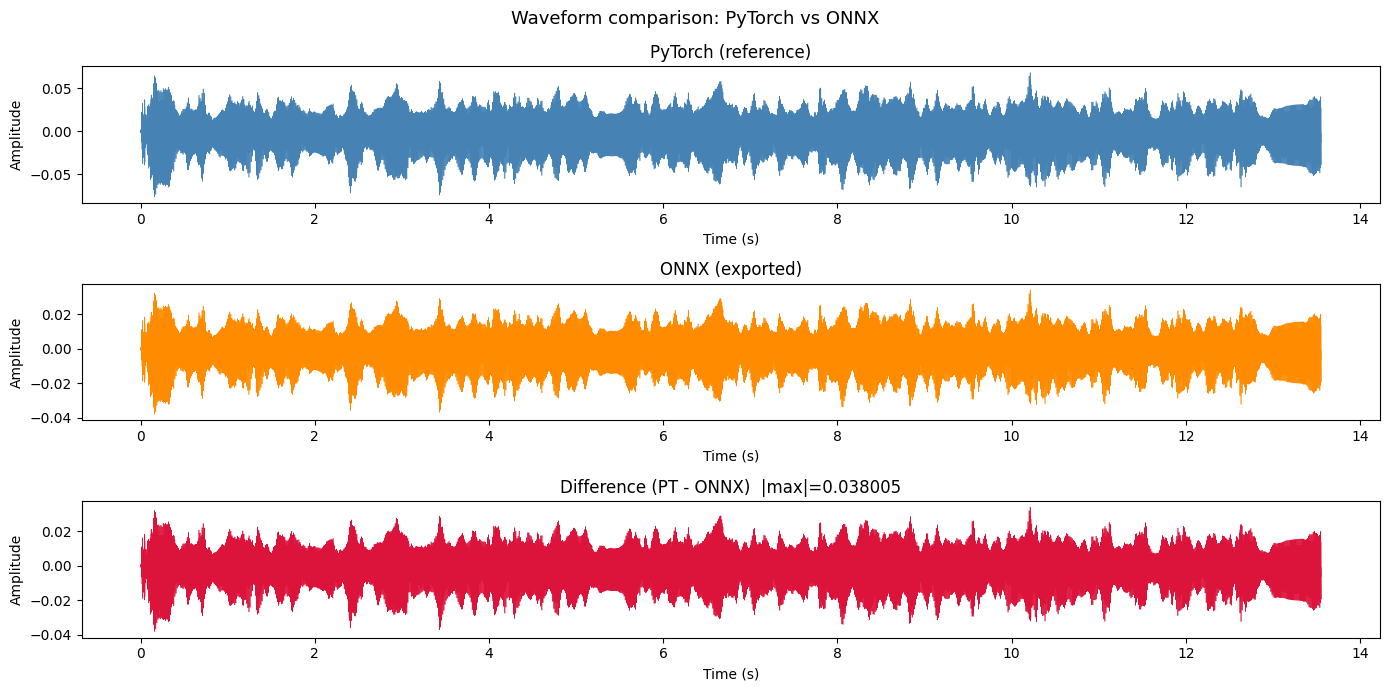

PyTorch audio:


ONNX audio:



Saved PT   wav : onnx_streaming_vocos/test_pt.wav
Saved ONNX wav : onnx_streaming_vocos/test_onnx.wav


In [30]:

# ── ONNX Validity Checks + Inference Test ────────────────────────────────────
import gc
import subprocess
import sys
import numpy as np
import onnx
import onnx.shape_inference
import onnxruntime as ort
import matplotlib.pyplot as plt
import scipy.io.wavfile as wavfile
from IPython.display import Audio, display


def _onnxsim_subprocess(model_path: str):
    """Run onnxsim in an isolated subprocess to prevent kernel crashes."""
    code = (
        "import onnxsim, onnx, sys; "
        f"m = onnx.load(r'{model_path}'); "
        "simplified, ok = onnxsim.simplify(m); "
        "print('OK' if ok else 'FAIL')"
    )
    try:
        result = subprocess.run(
            [sys.executable, "-c", code],
            capture_output=True, text=True, timeout=180,
        )
        if result.returncode == 0:
            ok = result.stdout.strip() == "OK"
            return "onnxsim OK" if ok else "onnxsim: could not simplify"
        else:
            stderr = result.stderr.strip()[:300]
            return f"onnxsim FAIL (rc={result.returncode}): {stderr}"
    except subprocess.TimeoutExpired:
        return "onnxsim TIMEOUT (>180 s)"
    except Exception as e:
        return f"onnxsim ERROR: {e}"


# ---------------------------------------------------------------------------
# 1. Validity checks on each exported model
# ---------------------------------------------------------------------------
print("=" * 60)
print("ONNX Validity Checks")
print("=" * 60)
for key, path in onnx_paths.items():
    m = onnx.load(str(path))

    try:
        onnx.checker.check_model(m)
        check_status = "check_model OK"
    except Exception as e:
        check_status = f"check_model FAIL: {e}"

    try:
        inferred = onnx.shape_inference.infer_shapes(
            m, check_type=True, strict_mode=True, data_prop=True
        )
        onnx.checker.check_model(inferred)
        infer_status = "shape_inference OK"
        del inferred
    except Exception as e:
        infer_status = f"shape_inference WARN: {e}"

    sim_status = _onnxsim_subprocess(str(path))

    try:
        _opts = ort.SessionOptions()
        _opts.intra_op_num_threads = 1
        ort.InferenceSession(str(path), sess_options=_opts, providers=["CPUExecutionProvider"])
        rt_status = "ORT session OK"
    except Exception as e:
        rt_status = f"ORT session FAIL: {e}"

    print(f"\n  [{key}]")
    print(f"    {check_status}")
    print(f"    {infer_status}")
    print(f"    {sim_status}")
    print(f"    {rt_status}")

    del m
    gc.collect()

# ---------------------------------------------------------------------------
# 2. Build OnnxRuntime inference sessions
# ---------------------------------------------------------------------------
print("\n" + "=" * 60)
print("Building OnnxRuntime sessions")
print("=" * 60)

_so = ort.SessionOptions()
_so.intra_op_num_threads = 8
_providers = ["CPUExecutionProvider"]

bert_sess  = ort.InferenceSession(str(onnx_paths["bert"]),               sess_options=_so, providers=_providers)
dur_sess   = ort.InferenceSession(str(onnx_paths["duration_predictor"]), sess_options=_so, providers=_providers)
f0n_sess   = ort.InferenceSession(str(onnx_paths["f0n_predictor"]),      sess_options=_so, providers=_providers)
cond_sess  = ort.InferenceSession(str(onnx_paths["vocoder_conditioner"]), sess_options=_so, providers=_providers)
stream_sess= ort.InferenceSession(str(onnx_paths["vocoder_stream_chunk"]), sess_options=_so, providers=_providers)

for label, sess in [("bert", bert_sess), ("duration_predictor", dur_sess),
                    ("f0n_predictor", f0n_sess),
                    ("vocoder_conditioner", cond_sess),
                    ("vocoder_stream_chunk", stream_sess)]:
    ins  = [f"{i.name}{list(i.shape)}" for i in sess.get_inputs()]
    outs = [f"{o.name}{list(o.shape)}" for o in sess.get_outputs()]
    print(f"  {label}")
    print(f"    inputs : {ins}")
    print(f"    outputs: {outs}")

# Derive state shapes from the stream_chunk session's input metadata
_stream_inputs = {i.name: i.shape for i in stream_sess.get_inputs()}
_STATE_EMBED_SHAPE  = _stream_inputs['embed_prev']     # [B, mch, KCTX]
_STATE_CNX_SHAPE    = _stream_inputs['cnx0_prev']       # [B, bdim, KCTX]
_STATE_ISTFT_SHAPE  = _stream_inputs['istft_buf']       # [B, tail]

print(f"\n  State shapes: embed={_STATE_EMBED_SHAPE}  cnx={_STATE_CNX_SHAPE}  istft={_STATE_ISTFT_SHAPE}")

# ---------------------------------------------------------------------------
# 3. Chunked streaming inference through ONNX sessions (explicit state)
# ---------------------------------------------------------------------------
def run_onnx_streaming(inp):
    """Full pipeline through ONNX sessions.

    Conditioner runs ONCE over the full feature sequence (avoids non-causal
    boundary artifacts).  The backbone+head chunk model receives and returns
    explicit streaming state tensors so continuity is maintained across chunks.
    """
    input_ids_np = inp["input_ids"].numpy()
    text_mask_np = inp["text_mask"].numpy()
    style_np     = inp["style"].numpy()
    speed_np     = inp["speed"].numpy()

    # -- Bert encoder
    (d_en_np,) = bert_sess.run(None, {
        "input_ids": input_ids_np,
        "text_mask": text_mask_np,
    })

    # -- Duration predictor
    pred_dur_np, en_np, asr_np = dur_sess.run(None, {
        "input_ids": input_ids_np,
        "d_en":      d_en_np,
        "style":     style_np,
        "text_mask": text_mask_np,
        "speed":     speed_np,
    })

    # -- F0 + N predictor
    f0_pred_np, n_pred_np = f0n_sess.run(None, {
        "en":    en_np,
        "style": style_np,
    })

    total_frames = int(f0_pred_np.shape[-1])

    # Upsample asr to f0 temporal resolution (2×) and build full features
    if asr_np.shape[-1] != total_frames:
        asr_t  = torch.from_numpy(asr_np)
        asr_t  = F.interpolate(asr_t.float(), size=total_frames, mode='linear', align_corners=False)
        asr_np = asr_t.numpy()

    B = asr_np.shape[0]
    s_np  = np.broadcast_to(style_np[:, :128, np.newaxis], (B, 128, total_frames))
    feat_np = np.concatenate([
        asr_np,
        f0_pred_np[:, np.newaxis, :],
        n_pred_np[:, np.newaxis, :],
        s_np,
    ], axis=1).astype(np.float32)

    # -- Conditioner (full sequence, one pass)
    (conditioned_np,) = cond_sess.run(None, {"features": feat_np})

    # -- Initialise streaming state (zeros)
    embed_prev  = np.zeros(_STATE_EMBED_SHAPE, dtype=np.float32)
    cnx_prevs   = [np.zeros(_STATE_CNX_SHAPE,  dtype=np.float32) for _ in range(8)]
    istft_buf   = np.zeros(_STATE_ISTFT_SHAPE,  dtype=np.float32)

    # -- Chunked backbone+head streaming
    audio_chunks = []
    pos = 0
    while pos < total_frames:
        end          = min(total_frames, pos + VOCOS_CHUNK_FRAMES)
        valid_frames = end - pos

        cond_c = conditioned_np[:, :, pos:end]
        if valid_frames < VOCOS_CHUNK_FRAMES:
            pad    = VOCOS_CHUNK_FRAMES - valid_frames
            cond_c = np.pad(cond_c, ((0, 0), (0, 0), (0, pad)))

        feed = {
            "conditioned_chunk": cond_c,
            "embed_prev":        embed_prev,
            **{f"cnx{i}_prev": cnx_prevs[i] for i in range(8)},
            "istft_buf":         istft_buf,
        }
        outs = stream_sess.run(None, feed)
        audio_c     = outs[0]
        embed_prev  = outs[1]
        cnx_prevs   = list(outs[2:10])
        istft_buf   = outs[10]

        audio_chunks.append(audio_c[..., :valid_frames * VOCOS_HOP_LENGTH])
        pos = end

    return np.concatenate(audio_chunks, axis=-1).squeeze()


print("\n" + "=" * 60)
print("Running ONNX chunked streaming inference")
print("=" * 60)
onnx_audio_np = run_onnx_streaming(inputs)
print(f"  PT   audio shape : {audio_np.shape}")
print(f"  ONNX audio shape : {onnx_audio_np.shape}")

min_len  = min(len(audio_np), len(onnx_audio_np))
max_diff = float(np.abs(audio_np[:min_len] - onnx_audio_np[:min_len]).max())
print(f"  Max |PT - ONNX|  : {max_diff:.6f}")

# ---------------------------------------------------------------------------
# 4. Waveform comparison plot
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=False)

t_pt   = np.arange(len(audio_np))      / SAMPLE_RATE
t_onnx = np.arange(len(onnx_audio_np)) / SAMPLE_RATE

axes[0].plot(t_pt, audio_np, linewidth=0.4, color="steelblue")
axes[0].set_title("PyTorch (reference)"); axes[0].set_ylabel("Amplitude"); axes[0].set_xlabel("Time (s)")

axes[1].plot(t_onnx, onnx_audio_np, linewidth=0.4, color="darkorange")
axes[1].set_title("ONNX (exported)"); axes[1].set_ylabel("Amplitude"); axes[1].set_xlabel("Time (s)")

diff   = audio_np[:min_len] - onnx_audio_np[:min_len]
t_diff = np.arange(min_len) / SAMPLE_RATE
axes[2].plot(t_diff, diff, linewidth=0.4, color="crimson")
axes[2].set_title(f"Difference (PT - ONNX)  |max|={max_diff:.6f}")
axes[2].set_ylabel("Amplitude"); axes[2].set_xlabel("Time (s)")

plt.suptitle("Waveform comparison: PyTorch vs ONNX", fontsize=13)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# 5. Audio playback
# ---------------------------------------------------------------------------
print("PyTorch audio:")
display(Audio(audio_np, rate=SAMPLE_RATE))
print("ONNX audio:")
display(Audio(onnx_audio_np, rate=SAMPLE_RATE))

# ---------------------------------------------------------------------------
# 6. Save WAV files
# ---------------------------------------------------------------------------
pt_wav_path   = EXPORT_DIR / "test_pt.wav"
onnx_wav_path = EXPORT_DIR / "test_onnx.wav"
wavfile.write(str(pt_wav_path),   SAMPLE_RATE, (audio_np      * 32767).astype("int16"))
wavfile.write(str(onnx_wav_path), SAMPLE_RATE, (onnx_audio_np * 32767).astype("int16"))
print(f"\nSaved PT   wav : {pt_wav_path}")
print(f"Saved ONNX wav : {onnx_wav_path}")


In [ ]:
def export_litert_modules(export_dir: Path, input_tensors, intermediate_tensors):
    if ai_edge_torch is None:
        raise ImportError('ai_edge_torch is not installed in this environment.')

    export_dir.mkdir(parents=True, exist_ok=True)

    input_ids = input_tensors['input_ids']
    text_mask = input_tensors['text_mask']
    style = input_tensors['style']
    speed = input_tensors['speed']

    d_en = intermediate_tensors['d_en']
    en = intermediate_tensors['en']

    bert_tflite = ai_edge_torch.convert(
        bert_module,
        sample_args=(input_ids, text_mask),
        strict_export=False,
    )
    bert_path = export_dir / 'bert.tflite'
    bert_tflite.export(str(bert_path))

    duration_path = export_dir / 'duration_predictor.tflite'
    try:
        duration_tflite = ai_edge_torch.convert(
            duration_module,
            sample_args=(input_ids, d_en, style, text_mask, speed),
            strict_export=False,
        )
        duration_tflite.export(str(duration_path))
    except Exception as exc:
        duration_path = None
        print(f'warning: duration_predictor.tflite export skipped: {type(exc).__name__}: {exc}')

    f0n_path = export_dir / 'f0n_predictor.tflite'
    try:
        f0n_tflite = ai_edge_torch.convert(
            f0n_module,
            sample_args=(en, style),
            strict_export=False,
        )
        f0n_tflite.export(str(f0n_path))
    except Exception as exc:
        f0n_path = None
        print(f'warning: f0n_predictor.tflite export skipped: {type(exc).__name__}: {exc}')

    asr_chunk, f0_chunk, n_chunk, style_128 = _first_vocoder_chunk(intermediate_tensors, style)
    vocoder_path = export_dir / 'vocoder_chunk.tflite'
    try:
        vocoder_tflite = ai_edge_torch.convert(
            vocoder_chunk_module,
            sample_args=(asr_chunk, f0_chunk, n_chunk, style_128),
            strict_export=False,
        )
        vocoder_tflite.export(str(vocoder_path))
    except Exception as exc:
        vocoder_path = None
        print(f'warning: vocoder_chunk.tflite export skipped: {type(exc).__name__}: {exc}')

    return {
        'bert': bert_path,
        'duration_predictor': duration_path,
        'f0n_predictor': f0n_path,
        'vocoder_chunk': vocoder_path,
    }


litert_paths = export_litert_modules(EXPORT_DIR, inputs, outputs)
print('LiteRT export complete:')
print(f'chunk_frames={VOCOS_CHUNK_FRAMES} chunk_samples={VOCOS_CHUNK_SAMPLES}')
for name, path in litert_paths.items():
    print(f'  {name}: {path}')
